# Cleaning

This notebook addresses cleaning, a fundamental preprocessing step in 3D pointcloud workflows. Real‑world pointclouds typically contain various forms of noise, outliers, and artifacts introduced by sensor imperfections or reconstruction errors. This severely degrade the quality of downstream tasks such as registration, segmentation, or feature extraction. Cleaning aims to improve the reliability and interpretability of pointclouds by removing points that are unlikely to represent the actual geometry of the scene. By filtering out noise and outliers, we obtain a dataset that is easier to process for subsequent algorithms that often assume a certain level of smoothness or geometric coherence.

This notebook focuses on outlier removal and desnoising, some of the most common cleaning operations applied in practice.

In [1]:
# Necessary imports
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

sys.path.append("./utils")
from manip_utils import orthonormal_basis_from_w

# Load our bunny pointcloud
data = np.loadtxt("./data/stanford_bunny_custom.xyz")
points = data[:, :3]
colors = data[:, 3:6]
normals = data[:, 9:12]
kdtree = KDTree(points)

## Outlier removal

Outliers are points that are geometrically inconsistent with their local neighborhood. They may appear isolated, too far from surfaces, or part of spurious structures caused by reflections, occlusions, or reconstruction noise.

Outlier‑removal algorithms aim to detect and eliminate such points by analyzing local spatial properties, such as distances or neighborhood statistics. This section presents two widely used techniques: *Statistical Outlier Removal* (SOR) and *Radius Outlier Removal* (ROR). Both rely on neighborhood queries but differ in how they classify a point as an outlier.

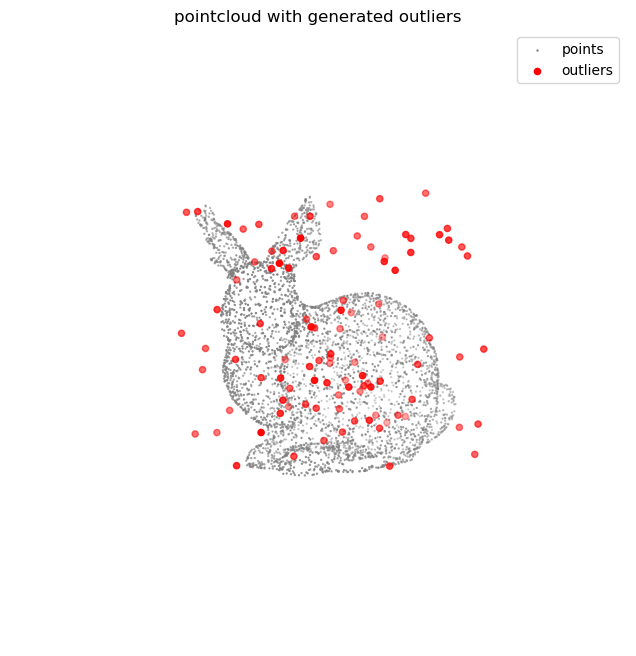

In [2]:
# Add outliers to the pointcloud
n_outliers = 100
outliers = np.random.uniform(
    points.min(axis=0),
    points.max(axis=0),
    (n_outliers, 3)
)
points_outliers = np.vstack((points, outliers))
# Create a mask to identify the outliers in the combined pointcloud
outliers_mask_true = np.hstack((np.zeros(points.shape[0], dtype=bool),
                                np.ones(outliers.shape[0], dtype=bool)))
# Build a KDTree for the pointcloud with outliers
kdtree_outliers = KDTree(points_outliers)

# Visualize the pointcloud with outliers
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c="grey", s=0.5, label="points")
ax.scatter(outliers[:, 0], outliers[:, 1], outliers[:, 2],
           c="red", label="outliers")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.legend()
plt.title("pointcloud with generated outliers")
plt.show()

### Statistical Outlier Removal (SOR)

Statistical Outlier Removal (SOR) is a statistics‑based filtering method that classifies points according to how unusual their local spacing is.

For each point, SOR computes the mean distance to its $k$ nearest neighbors. It then models the distribution of these mean distances across the entire pointcloud. Points whose mean distance deviates from the global distribution are considered statistical anomalies and removed. This is typically done by removing points lying more than a user‑defined number of standard deviations from the mean.

SOR is particularly suitable when noise is roughly evenly distributed and when a global statistical model makes sense.

In [3]:
def statistical_outlier_removal(points, neighbor_dist_function, std_ratio=2.0):
    """Remove points that are statistical outliers based on their average distance
     to neighbors."""

    # Compute the average distance to the nearest neighbors for each point
    dists = neighbor_dist_function(points)
    dists = dists[:, 1:]  # exclude the distance to itself
    avg_distances = np.mean(dists, axis=1)

    # Compute the mean and standard deviation of the average distances
    mean_distance = np.mean(avg_distances)
    std_distance = np.std(avg_distances)

    # Identify outliers based on the distance threshold
    threshold = mean_distance + std_ratio * std_distance
    outliers_mask = avg_distances > threshold

    return outliers_mask

Number of outliers: 72 (expected: 100)


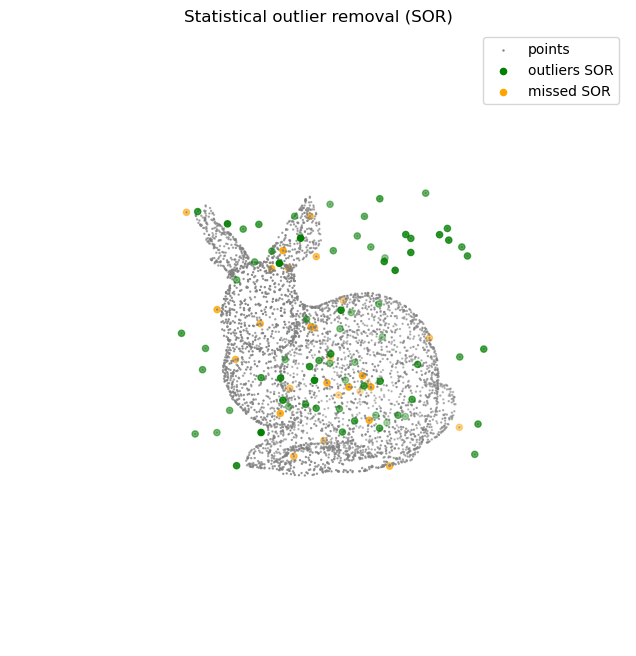

In [4]:
# Apply statistical outlier removal
neighbor_dist_function = lambda points: kdtree_outliers.query(points, k=10)[0]
outliers_mask_sor = statistical_outlier_removal(
    points_outliers,
    neighbor_dist_function,
    std_ratio=2.0
)
outliers_sor = points_outliers[outliers_mask_sor]
print(f"Number of outliers: {len(outliers_sor)} (expected: {n_outliers})")
missed_mask_sor = np.logical_xor(outliers_mask_sor, outliers_mask_true)
missed_sor = points_outliers[missed_mask_sor]

# Visualize the inliers and outliers
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_outliers[:, 0], points_outliers[:, 1], points_outliers[:, 2],
           c="grey", s=0.5, label="points")
ax.scatter(outliers_sor[:, 0], outliers_sor[:, 1], outliers_sor[:, 2],
           c="green", label="outliers SOR")
ax.scatter(missed_sor[:, 0], missed_sor[:, 1], missed_sor[:, 2],
           c="orange", label="missed SOR")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.legend()
plt.title("Statistical outlier removal (SOR)")
plt.show()


### Radius Outlier Removal (ROR)

Radius Outlier Removal (ROR) is a density‑based filtering method. Instead of analyzing global statistics, ROR examines local point density.

For each point, it counts how many neighbors lie within a given radius. If a point has fewer neighbors than a user‑defined threshold, it is considered to be in a locally sparse region and is removed.

This makes ROR well suited for eliminating isolated points or small clusters. ROR is especially helpful when point spacing is relatively uniform or when one wants to enforce a minimal local density.

In [5]:
def radius_outlier_removal(points, neighbor_finding_function, nb_points=5):
    """Remove points that have fewer than a specified number of neighbors within a given radius."""
    
    # Find neighbors within the specified radius for each point
    neighbors = neighbor_finding_function(points)

    # Count the number of neighbors for each point
    neighbor_counts = np.array([len(n) for n in neighbors])

    # Identify outliers based on the neighbor count threshold
    outliers_mask = neighbor_counts < nb_points

    return outliers_mask

Number of outliers: 72 (expected: 100)


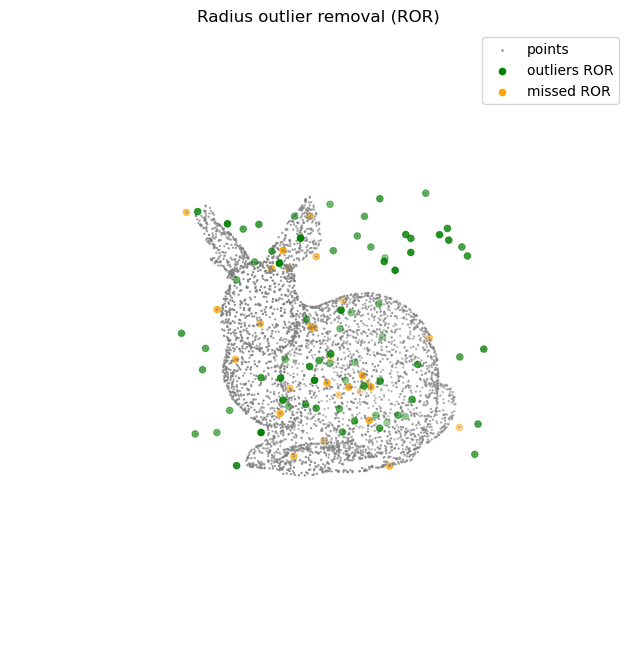

In [6]:
# Apply radius outlier removal
neighbor_finding_function = lambda points: kdtree_outliers.query_ball_point(points, r=10.)
outliers_mask_ror = radius_outlier_removal(
    points_outliers,
    neighbor_finding_function,
    nb_points=5
)
outliers_ror = points_outliers[outliers_mask_ror]
print(f"Number of outliers: {len(outliers_ror)} (expected: {n_outliers})")
missed_mask_ror = np.logical_xor(outliers_mask_ror, outliers_mask_true)
missed_ror = points_outliers[missed_mask_ror]

# Visualize the inliers and outliers
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_outliers[:, 0], points_outliers[:, 1], points_outliers[:, 2],
           c="grey", s=0.5, label="points")
ax.scatter(outliers_ror[:, 0], outliers_ror[:, 1], outliers_ror[:, 2],
           c="green", label="outliers ROR")
ax.scatter(missed_ror[:, 0], missed_ror[:, 1], missed_ror[:, 2],
           c="orange", label="missed ROR")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.legend()
plt.title("Radius outlier removal (ROR)")
plt.show()


### Going further

The previous sections introduced two widely used outlier‑removal techniques, Statistical Outlier Removal (SOR) and Radius Outlier Removal (ROR). Efficient implementations of these methods are available in most major pointcloud processing libraries, such as ```PCL``` (with ```StatisticalOutlierRemoval``` and ```RadiusOutlierRemoval```), ```Open3D``` (with ```remove_statistical_outlier``` and ```remove_radius_outlier```), and ```CGAL``` (with ```remove_outliers```). While these methods primarily rely on Euclidean distances, alternative criteria such as normal consistency or color similarity are sometimes incorporated.

SOR and ROR can be viewed as simple statistical filters operating on local neighborhoods. More elaborate techniques from the broader field of statistics extend these ideas but are often formulated for data in arbitrary dimensional spaces, without being specifically tailored to the geometric properties of 3D pointclouds. Similarly, learning‑based approaches identify outliers by learning patterns and deviations directly from data. An example tailored to 3D point clouds is PointCleanNet \cite{rakotosaona2020pointcleannet}, which uses deep neural networks to identify and correct outliers by analyzing local geometric patterns.

A distinct approach, often called model-based, consists of defining outliers as points that do not conform to an assumed geometric model. A common example is RANSAC‑based filtering, where surfaces such as planes or cylinders are robustly estimated and inconsistent points rejected (see notebook about segmentation). This approach is effective in scenes dominated by simple geometric primitives, but requires prior knowledge of the underlying surfaces and often manual parameter tuning.

In practice, outlier removal is rarely a one‑size‑fits‑all operation. Simple filters such as SOR and ROR are typically applied early in a processing pipeline to remove obvious outliers, while model‑based or learning‑based techniques are often employed at later stages, once the data has been roughly cleaned and structured.


## Denoising

Pointclouds are often affected by noise or small fluctuations in point positions caused by sensor inaccuracy or reconstruction artifacts. Unlike outliers, which are isolated and quite easy to identify, noise affects all points, subtly perturbing the surface geometry.

Denoising aims to smooth the pointcloud while preserving important geometric features, such as edges, corners, and fine details. The challenge is to reduce small‑scale noise without oversmoothing the underlying shape or blurring sharp transitions.

The following sections focus on some of the most widely used denoising techniques for pointclouds: the bilateral filter and the Moveing Least Squares filter.

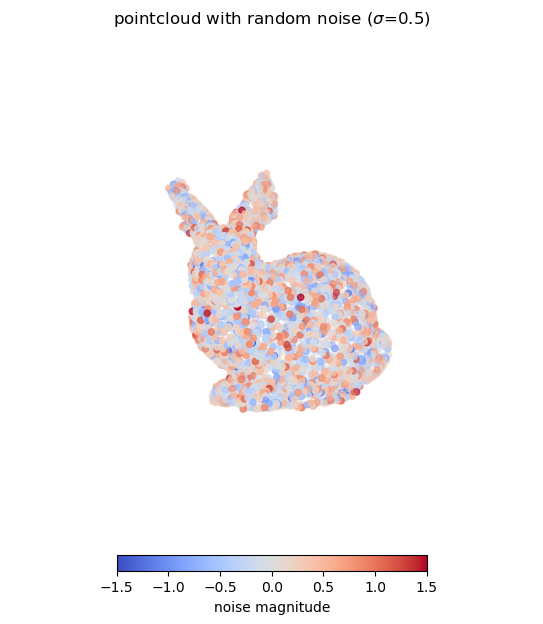

In [7]:
# Add noise to the pointcloud
sigma_noise = 0.5
noise = np.random.normal(scale=sigma_noise, size=len(points))
points_noise = points + noise[:, None] * normals

# Visualize the noisy pointcloud
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
norm = matplotlib.colors.TwoSlopeNorm(vcenter=0, vmin=-3*sigma_noise, vmax=3*sigma_noise)
im = ax.scatter(points_noise[:, 0], points_noise[:, 1], points_noise[:, 2],
           c=noise, cmap="coolwarm", norm=norm)
cbar = fig.colorbar(im, ax=ax, shrink=0.5,
                    location="bottom", orientation="horizontal", pad=0)
cbar.set_label("noise magnitude")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.title(f"pointcloud with random noise ($\\sigma$={sigma_noise})")
plt.show()


### Bilateral filter

The bilateral filter is a feature‑preserving smoothing technique that reduces noise while avoiding the blurring typical of classical averaging filters. Originally proposed for image denoising \cite{tomasi1998bilateral}, the bilateral filter was later extended to surface meshes \cite{fleishman2003bilateral} and subsequently to pointclouds \cite{digne2017bilateral}. The formulation presented below follows the pointcloud adaptation introduced in \cite{digne2017bilateral}.

Instead of simply taking the mean of neighboring points, it assigns a weight to each neighbor based on spatial proximity (closer points in space contribute more) and geometric similarity (points with similar normals contribute more). Thanks to this, points located across sharp features (i.e., having very different normals) contribute little to the smoothing process. As a result, the filter effectively denoises flat or smoothly curved regions while preserving sharp edges.

The algorithm is summarized as follows:

For each point $p_{i}$ with normal $n_{i}$:

1. Retrieve all neighbors within radius $r$ and form the set $N_{i}$:
\begin{equation*}
    N_{i} = \{ q_{j}, ||q_{j} - p_{i} || < r \}
\end{equation*}

2. Compute the Euclidean distances between $p_{i}$ and its neighbors:
\begin{equation*}
    d_{d}^{j} = || q_{j} - p_{i} ||
\end{equation*}

3. Compute the projected onto the normal $n_{i}$ distances between $p_{i}$ and its neighbors:
\begin{equation*}
    d_{n}^{j} = (q_{j} - p_{i}) \cdot n_{i}
\end{equation*}

4. Compute the bilateral weights associated with each neighbor:
\begin{equation*}
    w_{j} = e^{- \frac{d_{d}^{j 2}}{2 \sigma_{d}^{2}}} e^{- \frac{d_{n}^{j 2}}{2 \sigma_{n}^{2}}}
\end{equation*}

5. Compute the displacement scalar $\delta_{i}$ and move the point to its new position $p'_{i}$:
\begin{equation*}
    p'_{i} = \delta_{i} n_{i} \quad \text{with} \quad \delta_{i} = \frac{\sum_{q_{j} \in N_{i}} w_{j} d_{n}^{j}}{\sum_{q_{j} \in N_{i}} w_{j}}
\end{equation*}

This process can be repeated several times, resulting in $N$ iterations. The other and main parameters of the bilateral algorithms are then the radius $r$ used for the ball search and $\sigma_{d}$ and $\sigma_{n}$ the Gaussian weights for the Euclidean and projected distances. The article cited above proposes a coarse heuristic for setting their values, based on the assumption that the contribution of neighbors farther than $3 \sigma_{d}$ is negligible. This leads to $\sigma_{d} = \sigma_{n} = r/3$ and $r = L \sqrt{20/n}$ with $n$ the size of the pointcloud and $L$ the length of its cubic bounding box.

In practice this heuristic does not give the best result on our bunny pointcloud and smaller values are used in the example below.

In [8]:
def denoise_bilateral_filter(points, normals, neighbor_finding_function, sigma_d, sigma_n):
    """Bilateral filter for pointcloud"""
    
    points_denoised = np.empty_like(points)

    for i, (point, normal) in enumerate(zip(points, normals)):
        # Neighborhood search
        inds = neighbor_finding_function(point)
        neighbors = points[inds]
        # Distances
        d_dist = np.linalg.norm(neighbors - point, axis=1)
        # Projected distances
        d_normal = np.dot(neighbors - point, normal)
        # Weights
        weights = (
            np.exp(-(d_dist**2) / (2 * sigma_d**2)) # spatial weights
            * np.exp(-(d_normal**2) / (2 * sigma_n**2)) # normal weights
        )
        # Displacement along the normal
        delta_p = np.sum(weights * d_normal) / np.sum(weights)
        # New point position
        points_denoised[i] = point + delta_p * normal

    return points_denoised


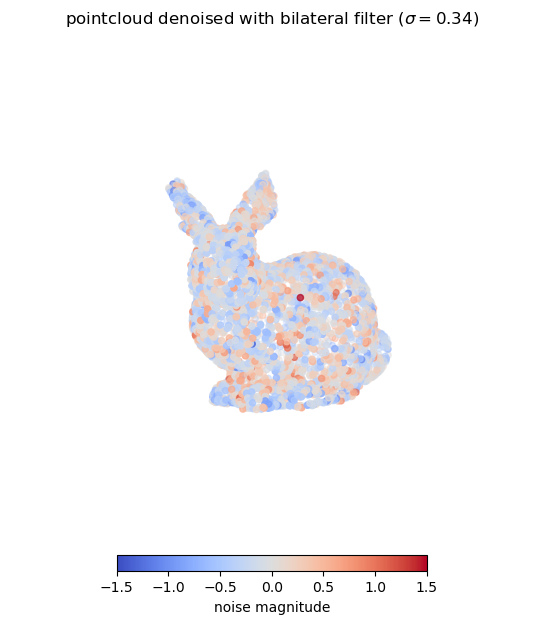

In [9]:
# Apply bilateral filter
neighbor_finding_function = lambda point: kdtree.query_ball_point(point, r=10.)
points_denoised_bilateral = denoise_bilateral_filter(
    points_noise,
    normals,
    neighbor_finding_function,
    sigma_d=2.,
    sigma_n=2.
)
noise_bilateral = np.sum(normals*(points_denoised_bilateral - points), axis=1)

# Visualize the denoised pointcloud
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
norm = matplotlib.colors.TwoSlopeNorm(vcenter=0, vmin=-3*sigma_noise, vmax=3*sigma_noise)
im = ax.scatter(points_denoised_bilateral[:, 0], points_denoised_bilateral[:, 1],
           points_denoised_bilateral[:, 2],
           c=noise_bilateral, cmap="coolwarm", norm=norm)
cbar = fig.colorbar(im, ax=ax, shrink=0.5,
                    location="bottom", orientation="horizontal", pad=0)
cbar.set_label("noise magnitude")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.title(f"pointcloud denoised with bilateral filter ($\\sigma={noise_bilateral.std():.2f})$")
plt.show()

### Moving Least Squares

Moving Least Squares (MLS) is a technique for approximating a smooth surface from an unstructured and possibly noisy pointcloud by fitting local surface models in a neighborhood of each point. The method was originally proposed for point‑set surface computation and rendering \cite{alexa2003computing} and is now a foundational technique in point‑based geometry processing.

The central idea of MLS is to define, for any point of interest, a local neighborhood and to estimate a surface by solving a weighted least‑squares problem, typically fitting a low‑degree polynomial. The weights are chosen as a decreasing function of distance, so that nearby points exert a stronger influence than distant ones. As the evaluation point moves across the pointcloud, both the neighborhood and the associated weights change continuously, causing the fitted surface to vary smoothly (hence the term moving least squares). A projection operator is then defined by mapping a point onto the locally approximated surface.

MLS has been widely used for surface reconstruction, resampling, and point‑based rendering. It can also be employed as a denoising technique by projecting each input point onto the MLS surface defined by the original point set, thereby reducing high‑frequency noise.

A simplified variant of MLS is considered below for denoising purposes. The overall procedure is outlined below:

For each point $p_{i}$ with unit normal $n_{i}$:

1. Retrieve all neighbors within radius $r$ and form the set $N_{i}$:
\begin{equation*}
    N_{i} = \{ q_{j}, ||q_{j} - p_{i} || < r \}
\end{equation*}
where the radius $r$ is chosen proportional to a scale parameter $h$ (typically $r = 2h$ to $3h$) used to assign each neighbor with a distance based weight:
\begin{equation*}
    \theta(d_{j}) = e^{-d_{j}^{2}/h^{2}} \quad \text{with} \quad d_{j} = || q_{j} - p_{i} ||
\end{equation*}

2. Define the local reference plane $H_{i}$ as passing through $p_{i}$ and having normal $n_{i}$ (avoiding optimization over normal and offset as described in the original paper). Choose two orthonormal tangent vectors $u_{i}$ and $v_{i}$ such that $(u_{i}, v_{i}, n_{i})$ is an orthonormal basis.

3. Project neighbors onto the plane $H_{i}$:
\begin{equation*}
    q'_{j} = q_{j} - (n_{i} \cdot (q_{j} - p_{i})) n_{i}
\end{equation*}

4. Compute local coordinates signed heights to the plane $H_{i}$:
\begin{equation*}
    x_{j} = u_{i} \cdot (q'_{j} - p_{i}) \qquad y_{j} = v_{i} \cdot (q'_{j} - p_{i}) \qquad f_{j} = n_{i} \cdot (q_{j} - p_{i})
\end{equation*}
yielding scattered height samples $(x_{j}, y_{j}, f_{j})$.

5. Fit a local MLS height function, typically a bivariate polynomial $g(x, y)$ of degree 3:
\begin{equation*}
    \min_{g} \sum_{q_{j} \in N_{i}} (g(x_{j}, y_{j}) - f_{j})^{2} \theta (|| q_{j} - p_{i} ||)
\end{equation*}

6. Compute the denoised point $p'_{i}$ by evaluating the fitted height at the origin of the local frame:
\begin{equation*}
    p'_{i} = p_{i} + g(0, 0) n_{i}
\end{equation*}

In particular, the optimization step required to estimate an optimal local reference plane is omitted. Instead, the reference plane is assumed to pass through the point being processed, with a known normal direction. As noted in the original paper \cite{alexa2003computing}, this approximation is reasonable when the input points are already close to the underlying surface and allows the computationally expensive nonlinear optimization to be avoided. For denoising applications, where only small displacements are expected, this simplification provides a favorable trade‑off between accuracy and efficiency.

The main parameter of the algorithm is the weighting scale $h$, which, as stated in the original work, should reflect the anticipated spacing between neighboring points. This parameter controls the locality of the surface approximation, as smaller values of $h$ lead to more localized fits that better preserve fine‑scale details, whereas larger values of $h$ result in smoother, more global approximations. 

As $h$ increases, sharp geometric features such as edges and corners tend to be smoothed out, highlighting a well‑known limitation of the standard MLS technique. Since it relies on local averaging and smooth polynomial surface representations, the preservation of sharp features generally requires additional strategies.

In [10]:
def MLS_denoise(points, normals, neighbor_finding_function, h):
    """Denoise a pointcloud using a simplified MLS projection."""
    
    points_denoised = np.empty_like(points)

    for i, point in enumerate(points):

        # Neighborhood search
        inds = neighbor_finding_function(point, 2.0*h)
        neighbors = points[inds]
        dists = np.linalg.norm(neighbors - point, axis=1)
        weights = np.exp(-dists**2/h**2)

        # Local reference frame
        u, v, n = orthonormal_basis_from_w(normals[i])

        # Project neighbors onto the local plane
        q_prime = neighbors - np.dot(neighbors - point, n)[:, None] * n
        
        # Compute local coordinates
        x = np.dot(q_prime - point, u)
        y = np.dot(q_prime - point, v)
        f = np.dot(neighbors - point, n)

        # Fit a local MLS height function (here bivariate polynomial of degree 3)
        A = np.column_stack((np.ones_like(x), x, y, x**2, x*y, y**2, x**3, x**2*y, x*y**2, y**3))
        A = weights[:, None] * A
        b = weights * f
        coeffs, *_ = np.linalg.lstsq(A, b, rcond=None)

        # Compute the denoised point by evaluating the fitted height at the origin
        g_00 = coeffs[0]  # g(0, 0) corresponds to the constant term of the polynomial
        points_denoised[i] = point + g_00 * n
        
    return points_denoised


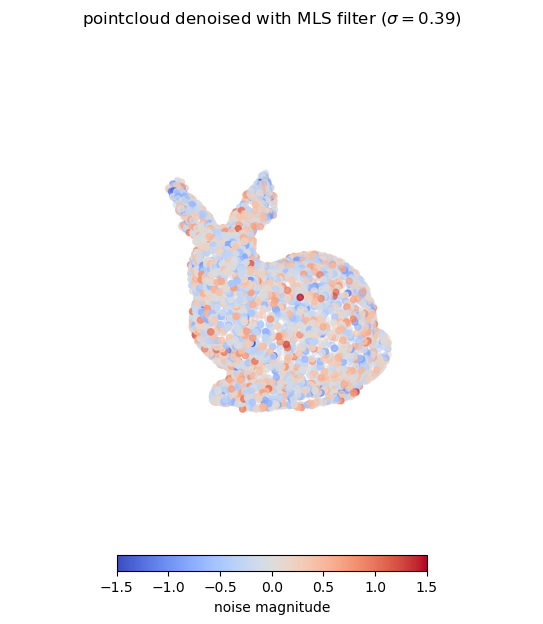

In [11]:
# Apply MLS denoising
neighbor_finding_function = lambda p, r: kdtree.query_ball_point(p, r)
points_denoised_MLS = MLS_denoise(
    points_noise,
    normals,
    neighbor_finding_function,
    h=5.
)
noise_MLS = np.sum(normals*(points_denoised_MLS - points), axis=1)

# Visualize the denoised pointcloud
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
norm = matplotlib.colors.TwoSlopeNorm(vcenter=0, vmin=-3*sigma_noise, vmax=3*sigma_noise)
im = ax.scatter(points_denoised_MLS[:, 0], points_denoised_MLS[:, 1],
           points_denoised_MLS[:, 2],
           c=noise_MLS, cmap="coolwarm", norm=norm)
cbar = fig.colorbar(im, ax=ax, shrink=0.5,
                    location="bottom", orientation="horizontal", pad=0)
cbar.set_label("noise magnitude")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.title(f"pointcloud denoised with MLS filter ($\\sigma={noise_MLS.std():.2f})$")
plt.show()


### Going further

Most classical denoising techniques for point clouds rely on local surface estimation followed by point projection. The underlying surface is typically modeled as a plane or a low‑degree polynomial, as illustrated by the bilateral filter and Moving Least Squares. Moving Least Squares is widely used in practice and is notably implemented in ```PCL``` as ```MovingLeastSquares```. A related alternative is jet fitting, which estimates higher‑order local surface approximations, with an implementation called ```jet_smooth_point_set``` found in ```CGAL```.

More recent approaches replace explicit surface fitting with data‑driven models. A representative example is PointCleanNet \cite{rakotosaona2020pointcleannet}, a neural network that learns priors from training data to infer clean point positions from noisy observations. These techniques can handle complex and structured noise patterns that are difficult to model analytically, but they require representative training datasets and introduce higher computational and implementation costs.

In practical pipelines, classical denoising methods remain widely used due to their simplicity, interpretability, and efficiency.

## Wrapping up

You should now have a clearer understanding of 3D pointcloud cleaning, including outlier removal, which targets isolated or inconsistent points, and denoising, which aims to reduce acquisition noise. Together, these operations form an essential preprocessing stage for many downstream tasks.

Outlier‑removal techniques such as SOR and ROR rely on neighborhood statistics and are well suited for eliminating gross artifacts early in a processing pipeline. In contrast, denoising techniques address subtler perturbations by estimating local surface structure and projecting points onto smoother representations, as illustrated by bilateral filtering and Moving Least Squares. The effectiveness of these techniques depends on assumptions about point density, noise and underlying geometry. 

In practice, pointcloud cleaning is an iterative and data‑dependent process. Simple, robust methods are typically applied first to stabilize the data, while more elaborate techniques may be used as refinement steps.